###### 132_2_practical_lcm_datetime_extract_real_answer.ipynb

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
pd.set_option("display.max_columns", None)
plt.rcParams["font.family"] = "Meiryo"


In [13]:
#cell3 
df = pd.read_csv("dataset/lcm_occurrence_datetime_real.csv", encoding="utf-8-sig")
df

,defect_id,site,customer,model,defect_category,defect_qty,occ_at,cm_status
0,D001,SUS,Honda,J69P,Buck-IC,3,2026-07-01 09:15:00+09:00,回答済
1,D002,WSE,Honda,310D,Coil,1,2026-07-01 14:30:00+09:00,回答済
2,D003,GSE,Mitsubishi,310D,NTF,1,2026-07-02 23:10:00+09:00,回答済
3,D004,MELMB,Honda,J69P,Buck-IC,2,2026/07/03 00:40,調査中
4,D005,SUS,Mitsubishi,310D,Coil,4,2026/07/04 08:20,回答済
5,D006,WSE,Honda,J69P,NTF,1,2026-07-04 18:45,回答済
6,D007,GSE,Honda,310D,Buck-IC,5,2026-07-05 21:30,回答済
7,D008,MELMB,Mitsubishi,J69P,Coil,2,2026-07-06 11:10:00+09:00,調査中
8,D009,SUS,Honda,310D,Coil,3,2026-08-01 07:55:00+09:00,回答済
9,D010,WSE,Mitsubishi,310D,Buck-IC,2,2026-08-02 15:30:00+09:00,回答済


In [14]:
df.dtypes

defect_id          object
site               object
customer           object
model              object
defect_category    object
defect_qty         object
occ_at             object
cm_status          object
dtype: object

In [15]:
df["defect_qty_raw"] = df["defect_qty"]

df[
    [
        "defect_id",
        "defect_qty",
        "defect_qty_raw",
    ]
]

,defect_id,defect_qty,defect_qty_raw
0,D001,3,3
1,D002,1,1
2,D003,1,1
3,D004,2,2
4,D005,4,4
5,D006,1,1
6,D007,5,5
7,D008,2,2
8,D009,3,3
9,D010,2,2


In [20]:
df["defect_qty_num"] = pd.to_numeric(
    df["defect_qty"],
    errors="coerce",
)
df["defect_qty_num"].dtype

df[
    [
        "defect_id",
        "defect_qty_raw",
        "defect_qty_num",
    ]
]

,defect_id,defect_qty_raw,defect_qty_num
0,D001,3,3.0
1,D002,1,1.0
2,D003,1,1.0
3,D004,2,2.0
4,D005,4,4.0
5,D006,1,1.0
6,D007,5,5.0
7,D008,2,2.0
8,D009,3,3.0
9,D010,2,2.0


In [23]:
df_invalid_qty = df[
    df["defect_qty_num"].isna()
].copy()

df_invalid_qty[
    [
        "defect_id",
        "site",
        "customer",
        "model",
        "defect_qty_raw",
        "defect_qty_num",
        "occ_at",
    ]
]


,defect_id,site,customer,model,defect_qty_raw,defect_qty_num,occ_at
15,D016,SUS,Honda,J69P,未入力,NaN,2026-08-08 09:00:00+09:00


In [24]:
df["occ_at_raw"] = df["occ_at"]

df[
    [
        "defect_id",
        "occ_at",
        "occ_at_raw",
    ]
]

,defect_id,occ_at,occ_at_raw
0,D001,2026-07-01 09:15:00+09:00,2026-07-01 09:15:00+09:00
1,D002,2026-07-01 14:30:00+09:00,2026-07-01 14:30:00+09:00
2,D003,2026-07-02 23:10:00+09:00,2026-07-02 23:10:00+09:00
3,D004,2026/07/03 00:40,2026/07/03 00:40
4,D005,2026/07/04 08:20,2026/07/04 08:20
5,D006,2026-07-04 18:45,2026-07-04 18:45
6,D007,2026-07-05 21:30,2026-07-05 21:30
7,D008,2026-07-06 11:10:00+09:00,2026-07-06 11:10:00+09:00
8,D009,2026-08-01 07:55:00+09:00,2026-08-01 07:55:00+09:00
9,D010,2026-08-02 15:30:00+09:00,2026-08-02 15:30:00+09:00


In [27]:
df["occ_at_clean"] = (
    df["occ_at"]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\+09:00$",
        "",
        regex=True,
    )
)
df[
    [
        "defect_id",
        "occ_at",
        "occ_at_clean",
    ]
]

,defect_id,occ_at,occ_at_clean
0,D001,2026-07-01 09:15:00+09:00,2026-07-01 09:15:00
1,D002,2026-07-01 14:30:00+09:00,2026-07-01 14:30:00
2,D003,2026-07-02 23:10:00+09:00,2026-07-02 23:10:00
3,D004,2026/07/03 00:40,2026/07/03 00:40
4,D005,2026/07/04 08:20,2026/07/04 08:20
5,D006,2026-07-04 18:45,2026-07-04 18:45
6,D007,2026-07-05 21:30,2026-07-05 21:30
7,D008,2026-07-06 11:10:00+09:00,2026-07-06 11:10:00
8,D009,2026-08-01 07:55:00+09:00,2026-08-01 07:55:00
9,D010,2026-08-02 15:30:00+09:00,2026-08-02 15:30:00


In [32]:
#cell 10
df["occ_at"] = pd.to_datetime(
    df["occ_at_clean"],
    format="mixed",
    errors="coerce"
)
df[
    [
        "defect_id",
        "occ_at_raw",
        "occ_at_clean",
        "occ_at",
    ]
].head().dtypes

defect_id               object
occ_at_raw              object
occ_at_clean    string[python]
occ_at          datetime64[ns]
dtype: object

In [34]:
df_invalid_date = df[
    df["occ_at"].isna()
].copy()

df_invalid_date[
    [
        "defect_id",
        "site",
        "customer",
        "model",
        "occ_at_raw",
        "occ_at_clean",
        "occ_at",
        "cm_status",
    ]
]



,defect_id,site,customer,model,occ_at_raw,occ_at_clean,occ_at,cm_status
16,D017,WSE,Mitsubishi,310D,NaN,<NA>,NaT,未回答
17,D018,GSE,Honda,J69P,2026-13-01 10:00:00,2026-13-01 10:00:00,NaT,調査中


In [35]:
df_work = df[
    df["occ_at"].notna()
].copy()
df_work

,defect_id,site,customer,model,defect_category,defect_qty,occ_at,cm_status,defect_qty_raw,defect_qty_num,occ_at_raw,occ_at_clean
0,D001,SUS,Honda,J69P,Buck-IC,3,2026-07-01 09:15:00,回答済,3,3.0,2026-07-01 09:15:00+09:00,2026-07-01 09:15:00
1,D002,WSE,Honda,310D,Coil,1,2026-07-01 14:30:00,回答済,1,1.0,2026-07-01 14:30:00+09:00,2026-07-01 14:30:00
2,D003,GSE,Mitsubishi,310D,NTF,1,2026-07-02 23:10:00,回答済,1,1.0,2026-07-02 23:10:00+09:00,2026-07-02 23:10:00
3,D004,MELMB,Honda,J69P,Buck-IC,2,2026-07-03 00:40:00,調査中,2,2.0,2026/07/03 00:40,2026/07/03 00:40
4,D005,SUS,Mitsubishi,310D,Coil,4,2026-07-04 08:20:00,回答済,4,4.0,2026/07/04 08:20,2026/07/04 08:20
5,D006,WSE,Honda,J69P,NTF,1,2026-07-04 18:45:00,回答済,1,1.0,2026-07-04 18:45,2026-07-04 18:45
6,D007,GSE,Honda,310D,Buck-IC,5,2026-07-05 21:30:00,回答済,5,5.0,2026-07-05 21:30,2026-07-05 21:30
7,D008,MELMB,Mitsubishi,J69P,Coil,2,2026-07-06 11:10:00,調査中,2,2.0,2026-07-06 11:10:00+09:00,2026-07-06 11:10:00
8,D009,SUS,Honda,310D,Coil,3,2026-08-01 07:55:00,回答済,3,3.0,2026-08-01 07:55:00+09:00,2026-08-01 07:55:00
9,D010,WSE,Mitsubishi,310D,Buck-IC,2,2026-08-02 15:30:00,回答済,2,2.0,2026-08-02 15:30:00+09:00,2026-08-02 15:30:00


In [36]:
len(df_work)

16

In [38]:
df_work["defect_qty_calc"] = (
    df_work["defect_qty_num"]
    .fillna(0)
    .astype(int)
)
df_work[
    [
        "defect_id",
        "defect_qty_raw",
        "defect_qty_num",
        "defect_qty_calc",
    ]
]

,defect_id,defect_qty_raw,defect_qty_num,defect_qty_calc
0,D001,3,3.0,3
1,D002,1,1.0,1
2,D003,1,1.0,1
3,D004,2,2.0,2
4,D005,4,4.0,4
5,D006,1,1.0,1
6,D007,5,5.0,5
7,D008,2,2.0,2
8,D009,3,3.0,3
9,D010,2,2.0,2


In [40]:
#cell 15

df_work["occ_date"] = df_work["occ_at"].dt.date

df_work[
    [
        "defect_id",
        "occ_at",
        "occ_date",
    ]
]

,defect_id,occ_at,occ_date
0,D001,2026-07-01 09:15:00,2026-07-01
1,D002,2026-07-01 14:30:00,2026-07-01
2,D003,2026-07-02 23:10:00,2026-07-02
3,D004,2026-07-03 00:40:00,2026-07-03
4,D005,2026-07-04 08:20:00,2026-07-04
5,D006,2026-07-04 18:45:00,2026-07-04
6,D007,2026-07-05 21:30:00,2026-07-05
7,D008,2026-07-06 11:10:00,2026-07-06
8,D009,2026-08-01 07:55:00,2026-08-01
9,D010,2026-08-02 15:30:00,2026-08-02


In [41]:
#cell 16

weekday_map = {
    0: "月曜日",
    1: "火曜日",
    2: "水曜日",
    3: "木曜日",
    4: "金曜日",
    5: "土曜日",
    6: "日曜日",
}

df_work["occ_weekday"] = (
    df_work["occ_at"]
    .dt.dayofweek
    .map(weekday_map)
)

df_work[
    [
        "defect_id",
        "occ_at",
        "occ_weekday"
    ]
]

,defect_id,occ_at,occ_weekday
0,D001,2026-07-01 09:15:00,水曜日
1,D002,2026-07-01 14:30:00,水曜日
2,D003,2026-07-02 23:10:00,木曜日
3,D004,2026-07-03 00:40:00,金曜日
4,D005,2026-07-04 08:20:00,土曜日
5,D006,2026-07-04 18:45:00,土曜日
6,D007,2026-07-05 21:30:00,日曜日
7,D008,2026-07-06 11:10:00,月曜日
8,D009,2026-08-01 07:55:00,土曜日
9,D010,2026-08-02 15:30:00,日曜日


In [43]:
#cell 17

df_work["occ_month"] = df_work["occ_at"].dt.strftime("%Y-%m")
df_work[
    [
        "defect_id",
        "occ_at",
        "occ_month"
    ]
]

,defect_id,occ_at,occ_month
0,D001,2026-07-01 09:15:00,2026-07
1,D002,2026-07-01 14:30:00,2026-07
2,D003,2026-07-02 23:10:00,2026-07
3,D004,2026-07-03 00:40:00,2026-07
4,D005,2026-07-04 08:20:00,2026-07
5,D006,2026-07-04 18:45:00,2026-07
6,D007,2026-07-05 21:30:00,2026-07
7,D008,2026-07-06 11:10:00,2026-07
8,D009,2026-08-01 07:55:00,2026-08
9,D010,2026-08-02 15:30:00,2026-08


In [44]:
df_work["occ_hour"] = df_work["occ_at"].dt.hour

df_work[
    [
        "defect_id",
        "occ_at",
        "occ_hour",
    ]
]

,defect_id,occ_at,occ_hour
0,D001,2026-07-01 09:15:00,9
1,D002,2026-07-01 14:30:00,14
2,D003,2026-07-02 23:10:00,23
3,D004,2026-07-03 00:40:00,0
4,D005,2026-07-04 08:20:00,8
5,D006,2026-07-04 18:45:00,18
6,D007,2026-07-05 21:30:00,21
7,D008,2026-07-06 11:10:00,11
8,D009,2026-08-01 07:55:00,7
9,D010,2026-08-02 15:30:00,15


In [46]:
df_work["occ_time_zone"] = ""

df_work.loc[
    df_work["occ_hour"].between(0, 5),
    "occ_time_zone",
] = "深夜"

df_work.loc[
    df_work["occ_hour"].between(6, 11),
    "occ_time_zone",
] = "午前"

df_work.loc[
    df_work["occ_hour"].between(12, 17),
    "occ_time_zone",
] = "午後"

df_work.loc[
    df_work["occ_hour"].between(18, 23),
    "occ_time_zone",
] = "夜間"

df_work[
    [
        "defect_id",
        "occ_hour",
        "occ_time_zone",
    ]
]

,defect_id,occ_hour,occ_time_zone
0,D001,9,午前
1,D002,14,午後
2,D003,23,夜間
3,D004,0,深夜
4,D005,8,午前
5,D006,18,夜間
6,D007,21,夜間
7,D008,11,午前
8,D009,7,午前
9,D010,15,午後


In [48]:
df_work["occ_quarter"] = (
    df_work["occ_at"].dt.year.astype(str)
    + "Q"
    + df_work["occ_at"].dt.quarter.astype(str)
)
df_work[
    [
        "defect_id",
        "occ_at",
        "occ_quarter",
    ]
]


,defect_id,occ_at,occ_quarter
0,D001,2026-07-01 09:15:00,2026Q3
1,D002,2026-07-01 14:30:00,2026Q3
2,D003,2026-07-02 23:10:00,2026Q3
3,D004,2026-07-03 00:40:00,2026Q3
4,D005,2026-07-04 08:20:00,2026Q3
5,D006,2026-07-04 18:45:00,2026Q3
6,D007,2026-07-05 21:30:00,2026Q3
7,D008,2026-07-06 11:10:00,2026Q3
8,D009,2026-08-01 07:55:00,2026Q3
9,D010,2026-08-02 15:30:00,2026Q3


In [49]:
#cell 21

df_work["holiday_flag"] = df_work["occ_weekday"].isin(
[
    "土曜日",
    "日曜日",
]
)
df_work[
    [
        "defect_id",
        "occ_weekday",
        "holiday_flag",
    ]
]

,defect_id,occ_weekday,holiday_flag
0,D001,水曜日,False
1,D002,水曜日,False
2,D003,木曜日,False
3,D004,金曜日,False
4,D005,土曜日,True
5,D006,土曜日,True
6,D007,日曜日,True
7,D008,月曜日,False
8,D009,土曜日,True
9,D010,日曜日,True


In [53]:
#cell 22

df_work["priority_check_flag"] = False

df_work.loc[
    (df_work["defect_qty_calc"] >= 3)
    | (df_work["occ_time_zone"].isin(["深夜", "夜間"]))
    | (df_work["holiday_flag"]),
    "priority_check_flag"
] = True

df_work[
    [
        "defect_id",
        "defect_qty_calc",
        "occ_time_zone",
        "holiday_flag",
        "priority_check_flag"
    ]
]

,defect_id,defect_qty_calc,occ_time_zone,holiday_flag,priority_check_flag
0,D001,3,午前,False,True
1,D002,1,午後,False,False
2,D003,1,夜間,False,True
3,D004,2,深夜,False,True
4,D005,4,午前,True,True
5,D006,1,夜間,True,True
6,D007,5,夜間,True,True
7,D008,2,午前,False,False
8,D009,3,午前,True,True
9,D010,2,午後,True,True


In [54]:
df_work[
    [
        "defect_id",
        "site",
        "customer",
        "model",
        "defect_category",
        "defect_qty_raw",
        "defect_qty_calc",
        "occ_at_raw",
        "occ_at",
        "occ_date",
        "occ_weekday",
        "occ_month",
        "occ_hour",
        "occ_time_zone",
        "occ_quarter",
        "holiday_flag",
        "priority_check_flag",
        "cm_status",
    ]
]

,defect_id,site,customer,model,defect_category,defect_qty_raw,defect_qty_calc,occ_at_raw,occ_at,occ_date,occ_weekday,occ_month,occ_hour,occ_time_zone,occ_quarter,holiday_flag,priority_check_flag,cm_status
0,D001,SUS,Honda,J69P,Buck-IC,3,3,2026-07-01 09:15:00+09:00,2026-07-01 09:15:00,2026-07-01,水曜日,2026-07,9,午前,2026Q3,False,True,回答済
1,D002,WSE,Honda,310D,Coil,1,1,2026-07-01 14:30:00+09:00,2026-07-01 14:30:00,2026-07-01,水曜日,2026-07,14,午後,2026Q3,False,False,回答済
2,D003,GSE,Mitsubishi,310D,NTF,1,1,2026-07-02 23:10:00+09:00,2026-07-02 23:10:00,2026-07-02,木曜日,2026-07,23,夜間,2026Q3,False,True,回答済
3,D004,MELMB,Honda,J69P,Buck-IC,2,2,2026/07/03 00:40,2026-07-03 00:40:00,2026-07-03,金曜日,2026-07,0,深夜,2026Q3,False,True,調査中
4,D005,SUS,Mitsubishi,310D,Coil,4,4,2026/07/04 08:20,2026-07-04 08:20:00,2026-07-04,土曜日,2026-07,8,午前,2026Q3,True,True,回答済
5,D006,WSE,Honda,J69P,NTF,1,1,2026-07-04 18:45,2026-07-04 18:45:00,2026-07-04,土曜日,2026-07,18,夜間,2026Q3,True,True,回答済
6,D007,GSE,Honda,310D,Buck-IC,5,5,2026-07-05 21:30,2026-07-05 21:30:00,2026-07-05,日曜日,2026-07,21,夜間,2026Q3,True,True,回答済
7,D008,MELMB,Mitsubishi,J69P,Coil,2,2,2026-07-06 11:10:00+09:00,2026-07-06 11:10:00,2026-07-06,月曜日,2026-07,11,午前,2026Q3,False,False,調査中
8,D009,SUS,Honda,310D,Coil,3,3,2026-08-01 07:55:00+09:00,2026-08-01 07:55:00,2026-08-01,土曜日,2026-08,7,午前,2026Q3,True,True,回答済
9,D010,WSE,Mitsubishi,310D,Buck-IC,2,2,2026-08-02 15:30:00+09:00,2026-08-02 15:30:00,2026-08-02,日曜日,2026-08,15,午後,2026Q3,True,True,回答済


In [56]:
df_weekday_summary = df_work.groupby(
    "occ_weekday",
    as_index=False,
).agg(
    defect_count=("defect_id", "count"),
    defect_qty_sum=("defect_qty_calc","sum")
)
df_weekday_summary

,occ_weekday,defect_count,defect_qty_sum
0,土曜日,4,8
1,日曜日,2,7
2,月曜日,2,3
3,木曜日,2,5
4,水曜日,3,6
5,火曜日,1,1
6,金曜日,2,3


In [58]:
weekday_order =[
    "月曜日",
    "火曜日",
    "水曜日",
    "木曜日",
    "金曜日",
    "土曜日",
    "日曜日",
]

df_weekday_summary["weekday_order"] = pd.Categorical(
    df_weekday_summary["occ_weekday"],
    categories=weekday_order,
    ordered=True,
)
df_weekday_summary = df_weekday_summary.sort_values(
    "weekday_order",
).drop(
    columns="weekday_order",
).reset_index(
    drop=True,
)

df_weekday_summary

,occ_weekday,defect_count,defect_qty_sum
0,月曜日,2,3
1,火曜日,1,1
2,水曜日,3,6
3,木曜日,2,5
4,金曜日,2,3
5,土曜日,4,8
6,日曜日,2,7


In [59]:
#cell 26
df_time_zone_summary = df_work.groupby(
    "occ_time_zone",
    as_index=False,
).agg(
    defect_count=("defect_id", "count"),
    defect_qty_sum=("defect_qty_calc", "sum"),
)
df_time_zone_summary

,occ_time_zone,defect_count,defect_qty_sum
0,午前,6,13
1,午後,3,5
2,夜間,5,12
3,深夜,2,3


In [61]:
time_zone_order = [
    "深夜",
    "午前",
    "午後",
    "夜間"
]

df_time_zone_summary["time_zone_order"] = pd.Categorical(
    df_time_zone_summary["occ_time_zone"],
    categories=time_zone_order,
    ordered=True,
)

df_time_zone_summary = df_time_zone_summary.sort_values(
    "time_zone_order",
).drop(
    columns="time_zone_order",
).reset_index(
    drop=True,
)
df_time_zone_summary

,occ_time_zone,defect_count,defect_qty_sum
0,深夜,2,3
1,午前,6,13
2,午後,3,5
3,夜間,5,12


In [62]:
#cell 28

df_month_site_summary = df_work.groupby(
    [
        "occ_month",
        "site",
    ],
    as_index=False,
).agg(
    defect_count=("defect_id", "count"),
    defect_qty_sum=("defect_qty_calc", "sum"),
)
df_month_site_summary = df_month_site_summary.sort_values(
    [
        "occ_month",
        "site",
    ]
).reset_index(
    drop=True,
)
df_month_site_summary

,occ_month,site,defect_count,defect_qty_sum
0,2026-07,GSE,2,6
1,2026-07,MELMB,2,4
2,2026-07,SUS,2,7
3,2026-07,WSE,2,2
4,2026-08,GSE,2,5
5,2026-08,MELMB,1,1
6,2026-08,SUS,3,4
7,2026-08,WSE,2,4


In [63]:
df_prirority_check = df_work[
    df_work["priority_check_flag"]
].copy()

In [67]:
df_prirority_check = df_prirority_check.sort_values(
    [
        "defect_qty_calc",
        "occ_at",
    ],
    ascending=[
        False,
        True,
    ],
).reset_index(
    drop=True,
)
df_prirority_check[
    [
        "defect_id",
        "site",
        "customer",
        "model",
        "defect_category",
        "defect_qty_raw",
        "defect_qty_calc",
        "occ_at",
        "occ_weekday",
        "occ_time_zone",
        "holiday_flag",
        "priority_check_flag",
        "cm_status",
    ]
]

,defect_id,site,customer,model,defect_category,defect_qty_raw,defect_qty_calc,occ_at,occ_weekday,occ_time_zone,holiday_flag,priority_check_flag,cm_status
0,D007,GSE,Honda,310D,Buck-IC,5,5,2026-07-05 21:30:00,日曜日,夜間,True,True,回答済
1,D005,SUS,Mitsubishi,310D,Coil,4,4,2026-07-04 08:20:00,土曜日,午前,True,True,回答済
2,D014,GSE,Mitsubishi,310D,Buck-IC,4,4,2026-08-06 19:50:00,木曜日,夜間,False,True,回答済
3,D001,SUS,Honda,J69P,Buck-IC,3,3,2026-07-01 09:15:00,水曜日,午前,False,True,回答済
4,D009,SUS,Honda,310D,Coil,3,3,2026-08-01 07:55:00,土曜日,午前,True,True,回答済
5,D004,MELMB,Honda,J69P,Buck-IC,2,2,2026-07-03 00:40:00,金曜日,深夜,False,True,調査中
6,D010,WSE,Mitsubishi,310D,Buck-IC,2,2,2026-08-02 15:30:00,日曜日,午後,True,True,回答済
7,D003,GSE,Mitsubishi,310D,NTF,1,1,2026-07-02 23:10:00,木曜日,夜間,False,True,回答済
8,D006,WSE,Honda,J69P,NTF,1,1,2026-07-04 18:45:00,土曜日,夜間,True,True,回答済
9,D011,GSE,Honda,J69P,Coil,1,1,2026-08-03 22:10:00,月曜日,夜間,False,True,調査中


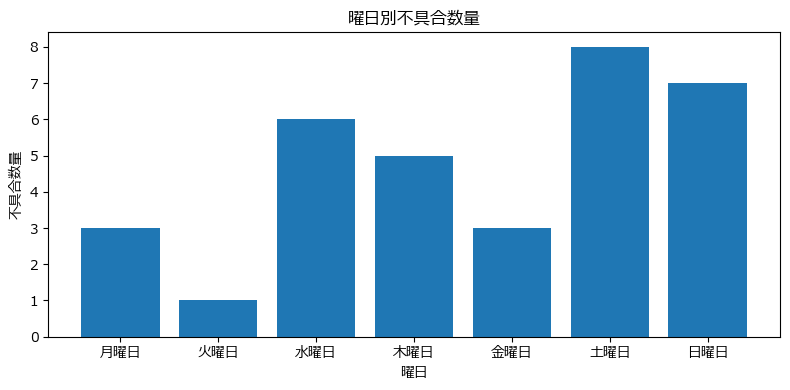

In [74]:
#cell 30

plt.figure(figsize=(8, 4))

plt.bar(
    df_weekday_summary["occ_weekday"],
    df_weekday_summary["defect_qty_sum"]
)

plt.title("曜日別不具合数量")
plt.xlabel("曜日")
plt.ylabel("不具合数量")

plt.tight_layout()
plt.show()

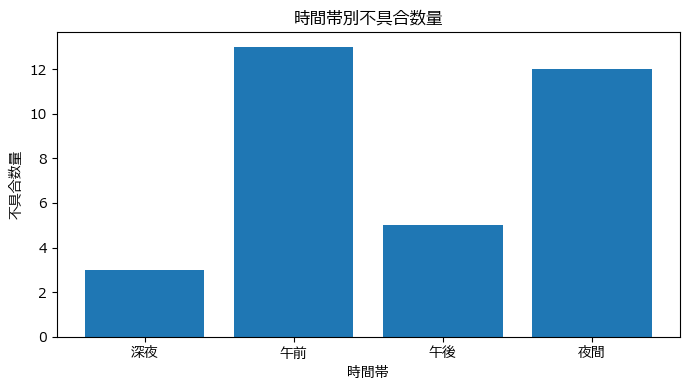

In [79]:
#cell 31

plt.figure(figsize=(7, 4))

plt.bar(
    df_time_zone_summary["occ_time_zone"],
    df_time_zone_summary["defect_qty_sum"]
)

plt.title("時間帯別不具合数量")
plt.xlabel("時間帯")
plt.ylabel("不具合数量")

plt.tight_layout()
plt.show()